In [ ]:
!pip install -q ucimlrepo

import os
import json
import warnings
import numpy as np
import pandas as pd

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("data/audit", exist_ok=True)

print("Project directories created.")

print("=" * 60)
print("DATA ACQUISITION")
print("=" * 60)

heart_disease = fetch_ucirepo(id=45)

X_raw = heart_disease.data.features.copy()
y_raw = heart_disease.data.targets.copy()

print("Dataset successfully acquired.")
print("Feature shape:", X_raw.shape)
print("Target shape:", y_raw.shape)

source_info = {
    "dataset": "UCI Heart Disease",
    "UCI_dataset_id": 45,
    "source": "UCI Machine Learning Repository",
    "task": "Heart Disease Classification",
    "target_original": "num",
    "target_transformation": "num > 0 -> 1, num = 0 -> 0",
    "random_state": RANDOM_STATE
}

with open("data/audit/source_info.json", "w") as f:
    json.dump(source_info, f, indent=4)

print("\nSource information saved.")

df = X_raw.copy()
df["num"] = y_raw["num"].values

print("\nInitial dataset shape:", df.shape)
print(df.head())

print("\n" + "=" * 60)
print("SCHEMA VALIDATION")
print("=" * 60)

expected_features = [
    "age",
    "sex",
    "cp",
    "trestbps",
    "chol",
    "fbs",
    "restecg",
    "thalach",
    "exang",
    "oldpeak",
    "slope",
    "ca",
    "thal"
]

expected_columns = expected_features + ["num"]

missing_columns = [
    col for col in expected_columns
    if col not in df.columns
]

unexpected_columns = [
    col for col in df.columns
    if col not in expected_columns
]

if missing_columns:
    raise ValueError(
        f"Schema validation failed. Missing columns: {missing_columns}"
    )

if unexpected_columns:
    print("Warning: Unexpected columns:", unexpected_columns)

print("Schema validation PASSED.")
print("Expected columns found:", len(expected_columns))

print("\nData types:")

dtype_audit = pd.DataFrame({
    "column": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "missing_count": df.isnull().sum().values,
    "unique_values": df.nunique().values
})

print(dtype_audit)

dtype_audit.to_csv(
    "data/audit/schema_audit.csv",
    index=False
)

print("\nSchema audit saved.")

audit = []

for column in df.columns:

    audit.append({
        "column": column,
        "dtype": str(df[column].dtype),
        "rows": len(df),
        "missing_count": int(df[column].isnull().sum()),
        "missing_percentage": round(
            df[column].isnull().mean() * 100, 2
        ),
        "unique_values": int(df[column].nunique()),
        "duplicate_count": int(df[column].duplicated().sum())
    })

quality_audit = pd.DataFrame(audit)

print("\nInitial Data Quality Audit:")
display(quality_audit)

quality_audit.to_csv(
    "data/audit/data_quality_before_cleaning.csv",
    index=False
)

print("\n" + "=" * 60)
print("DUPLICATE RECORD CHECK")
print("=" * 60)

duplicate_count = df.duplicated().sum()

print("Duplicate records:", duplicate_count)

if duplicate_count > 0:

    df = df.drop_duplicates().reset_index(drop=True)

    print(
        f"Removed {duplicate_count} duplicate records."
    )

else:
    print("No duplicate records found.")

print("\n" + "=" * 60)
print("INVALID RECORD VALIDATION")
print("=" * 60)

invalid_counts = {}

invalid_counts["age"] = (df["age"] <= 0).sum()

invalid_counts["trestbps"] = (df["trestbps"] <= 0).sum()

invalid_counts["chol"] = (df["chol"] <= 0).sum()

invalid_counts["thalach"] = (df["thalach"] <= 0).sum()

invalid_counts["num"] = (
    ~df["num"].isin([0, 1, 2, 3, 4])
).sum()

invalid_audit = pd.DataFrame(
    list(invalid_counts.items()),
    columns=["column", "invalid_count"]
)

print(invalid_audit)

invalid_audit.to_csv(
    "data/audit/invalid_records.csv",
    index=False
)

before_invalid_removal = len(df)

df = df[
    (df["age"] > 0) &
    (df["trestbps"] > 0) &
    (df["chol"] > 0) &
    (df["thalach"] > 0) &
    (df["num"].isin([0, 1, 2, 3, 4]))
].copy()

after_invalid_removal = len(df)

print(
    "Invalid records removed:",
    before_invalid_removal - after_invalid_removal
)

print("\n" + "=" * 60)
print("TARGET TRANSFORMATION")
print("=" * 60)

df["target"] = (df["num"] > 0).astype(int)

df.drop(columns=["num"], inplace=True)

print("\nBinary target distribution:")
print(df["target"].value_counts())

print("\nTarget percentages:")
print(
    df["target"].value_counts(normalize=True).mul(100).round(2)
)

X = df.drop(columns=["target"])
y = df["target"]

print("\nFeatures:", X.shape)
print("Target:", y.shape)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\n" + "=" * 60)
print("TRAIN / TEST SPLIT")
print("=" * 60)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print(
    "\nTraining target distribution:\n",
    y_train.value_counts(normalize=True)
)

print(
    "\nTesting target distribution:\n",
    y_test.value_counts(normalize=True)
)

print("\n" + "=" * 60)
print("OUTLIER DETECTION")
print("=" * 60)

numeric_features = X_train.select_dtypes(
    include=np.number
).columns.tolist()

outlier_report = []

for column in numeric_features:

    Q1 = X_train[column].quantile(0.25)
    Q3 = X_train[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    train_outliers = (
        (X_train[column] < lower) |
        (X_train[column] > upper)
    ).sum()

    test_outliers = (
        (X_test[column] < lower) |
        (X_test[column] > upper)
    ).sum()

    outlier_report.append({
        "feature": column,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower,
        "upper_bound": upper,
        "train_outliers": train_outliers,
        "test_outliers": test_outliers
    })

outlier_report = pd.DataFrame(outlier_report)

display(outlier_report)

outlier_report.to_csv(
    "data/audit/outlier_report.csv",
    index=False
)

class IQRClipper(BaseEstimator, TransformerMixin):

    def __init__(self, factor=1.5):
        self.factor = factor

    def fit(self, X, y=None):

        X_df = pd.DataFrame(X)

        self.lower_bounds_ = (
            X_df.quantile(0.25)
            - self.factor *
            (X_df.quantile(0.75) - X_df.quantile(0.25))
        )

        self.upper_bounds_ = (
            X_df.quantile(0.75)
            + self.factor *
            (X_df.quantile(0.75) - X_df.quantile(0.25))
        )

        return self

    def transform(self, X):

        X_df = pd.DataFrame(X).copy()

        for column in X_df.columns:

            X_df[column] = X_df[column].clip(
                lower=self.lower_bounds_[column],
                upper=self.upper_bounds_[column]
            )

        return X_df.values

print("\n" + "=" * 60)
print("BUILDING PREPROCESSING PIPELINE")
print("=" * 60)

preprocessing_pipeline = Pipeline([

    (
        "imputer",
        SimpleImputer(strategy="median")
    ),

    (
        "outlier_clipper",
        IQRClipper(factor=1.5)
    ),

    (
        "scaler",
        StandardScaler()
    )
])

print("Fitting preprocessing pipeline on TRAINING data...")

X_train_processed = preprocessing_pipeline.fit_transform(
    X_train
)

print("Training preprocessing complete.")

print("Transforming TEST data using training parameters...")

X_test_processed = preprocessing_pipeline.transform(
    X_test
)

print("Testing preprocessing complete.")

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=X_train.columns,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=X_test.columns,
    index=X_test.index
)

print("\n" + "=" * 60)
print("POST-PROCESSING QUALITY CHECK")
print("=" * 60)

print(
    "Training missing values:",
    X_train_processed.isnull().sum().sum()
)

print(
    "Testing missing values:",
    X_test_processed.isnull().sum().sum()
)

assert X_train_processed.isnull().sum().sum() == 0
assert X_test_processed.isnull().sum().sum() == 0

print("Missing-value validation PASSED.")

print("\n" + "=" * 60)
print("DATA DRIFT CHECK")
print("=" * 60)

def calculate_psi(expected, actual, bins=10):

    expected = np.asarray(expected)
    actual = np.asarray(actual)

    breakpoints = np.percentile(
        expected,
        np.linspace(0, 100, bins + 1)
    )

    breakpoints = np.unique(breakpoints)

    if len(breakpoints) < 3:
        return 0.0

    expected_counts = np.histogram(
        expected,
        bins=breakpoints
    )[0]

    actual_counts = np.histogram(
        actual,
        bins=breakpoints
    )[0]

    expected_pct = expected_counts / len(expected)
    actual_pct = actual_counts / len(actual)

    expected_pct = np.where(
        expected_pct == 0,
        0.0001,
        expected_pct
    )

    actual_pct = np.where(
        actual_pct == 0,
        0.0001,
        actual_pct
    )

    psi = np.sum(
        (actual_pct - expected_pct)
        * np.log(actual_pct / expected_pct)
    )

    return psi

drift_results = []

for column in X_train.columns:

    psi_value = calculate_psi(
        X_train[column].dropna(),
        X_test[column].dropna()
    )

    if psi_value < 0.10:
        status = "Low Drift"

    elif psi_value < 0.25:
        status = "Moderate Drift"

    else:
        status = "Significant Drift"

    drift_results.append({
        "feature": column,
        "PSI": round(psi_value, 4),
        "drift_status": status
    })

drift_report = pd.DataFrame(drift_results)

display(drift_report)

drift_report.to_csv(
    "data/audit/data_drift_report.csv",
    index=False
)

train_matrix = X_train_processed.copy()

train_matrix["target"] = y_train.values

train_matrix.to_csv(
    "data/processed/train_features.csv",
    index=False
)

test_matrix = X_test_processed.copy()

test_matrix["target"] = y_test.values

test_matrix.to_csv(
    "data/processed/test_features.csv",
    index=False
)

final_audit = []

for column in X_train_processed.columns:

    final_audit.append({

        "feature": column,

        "train_missing":
            int(X_train_processed[column].isnull().sum()),

        "test_missing":
            int(X_test_processed[column].isnull().sum()),

        "train_mean":
            round(X_train_processed[column].mean(), 4),

        "train_std":
            round(X_train_processed[column].std(), 4),

        "test_mean":
            round(X_test_processed[column].mean(), 4),

        "test_std":
            round(X_test_processed[column].std(), 4),

        "data_type":
            str(X_train_processed[column].dtype)

    })

final_quality_audit = pd.DataFrame(final_audit)

final_quality_audit.to_csv(
    "data/audit/final_data_quality_audit.csv",
    index=False
)

y_train.to_csv(
    "data/processed/y_train.csv",
    index=False
)

y_test.to_csv(
    "data/processed/y_test.csv",
    index=False
)

print("\n" + "=" * 60)
print("DATA ENGINEER PIPELINE COMPLETE")
print("=" * 60)

print("\nFinal Training Matrix:")
print(X_train_processed.shape)

print("\nFinal Testing Matrix:")
print(X_test_processed.shape)

print("\nGenerated Files:")
print("""
data/
├── raw/
│
├── processed/
│   ├── train_features.csv
│   ├── test_features.csv
│   ├── y_train.csv
│   └── y_test.csv
│
└── audit/
    ├── source_info.json
    ├── schema_audit.csv
    ├── data_quality_before_cleaning.csv
    ├── invalid_records.csv
    ├── outlier_report.csv
    ├── data_drift_report.csv
    └── final_data_quality_audit.csv
""")

print("\nLeakage Prevention:")
print("""
✓ Train/test split performed BEFORE preprocessing
✓ Imputer fitted only on training data
✓ Outlier boundaries calculated only from training data
✓ Scaler fitted only on training data
✓ Test data only transformed using training parameters
""")

print("\nData Engineer pipeline successfully completed.")

Project directories created.
DATA ACQUISITION
Dataset successfully acquired.
Feature shape: (303, 13)
Target shape: (303, 1)

Source information saved.

Initial dataset shape: (303, 14)
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   63    1   1       145   233    1        2      150      0      2.3      3   
1   67    1   4       160   286    0        2      108      1      1.5      2   
2   67    1   4       120   229    0        2      129      1      2.6      2   
3   37    1   3       130   250    0        0      187      0      3.5      3   
4   41    0   2       130   204    0        2      172      0      1.4      1   

    ca  thal  num  
0  0.0   6.0    0  
1  3.0   3.0    2  
2  2.0   7.0    1  
3  0.0   3.0    0  
4  0.0   3.0    0  

SCHEMA VALIDATION
Schema validation PASSED.
Expected columns found: 14

Data types:
      column    dtype  missing_count  unique_values
0        age    int64              0             41
1        sex    in

,column,dtype,rows,missing_count,missing_percentage,unique_values,duplicate_count
0,age,int64,303,0,0.00,41,262
1,sex,int64,303,0,0.00,2,301
2,cp,int64,303,0,0.00,4,299
3,trestbps,int64,303,0,0.00,50,253
4,chol,int64,303,0,0.00,152,151
5,fbs,int64,303,0,0.00,2,301
6,restecg,int64,303,0,0.00,3,300
7,thalach,int64,303,0,0.00,91,212
8,exang,int64,303,0,0.00,2,301
9,oldpeak,float64,303,0,0.00,40,263



DUPLICATE RECORD CHECK
Duplicate records: 0
No duplicate records found.

INVALID RECORD VALIDATION
     column  invalid_count
0       age              0
1  trestbps              0
2      chol              0
3   thalach              0
4       num              0
Invalid records removed: 0

TARGET TRANSFORMATION

Binary target distribution:
target
0    164
1    139
Name: count, dtype: int64

Target percentages:
target
0    54.13
1    45.87
Name: proportion, dtype: float64

Features: (303, 13)
Target: (303,)

TRAIN / TEST SPLIT
Training samples: 242
Testing samples: 61

Training target distribution:
 target
0    0.541322
1    0.458678
Name: proportion, dtype: float64

Testing target distribution:
 target
0    0.540984
1    0.459016
Name: proportion, dtype: float64

OUTLIER DETECTION


,feature,Q1,Q3,IQR,lower_bound,upper_bound,train_outliers,test_outliers
0,age,48.00,61.00,13.00,28.500,80.500,0,0
1,sex,0.00,1.00,1.00,-1.500,2.500,0,0
2,cp,2.25,4.00,1.75,-0.375,6.625,0,0
3,trestbps,120.00,140.00,20.00,90.000,170.000,6,3
4,chol,212.00,277.75,65.75,113.375,376.375,5,0
5,fbs,0.00,0.00,0.00,0.000,0.000,35,10
6,restecg,0.00,2.00,2.00,-3.000,5.000,0,0
7,thalach,134.50,166.00,31.50,87.250,213.250,1,0
8,exang,0.00,1.00,1.00,-1.500,2.500,0,0
9,oldpeak,0.00,1.60,1.60,-2.400,4.000,4,1



BUILDING PREPROCESSING PIPELINE
Fitting preprocessing pipeline on TRAINING data...
Training preprocessing complete.
Transforming TEST data using training parameters...
Testing preprocessing complete.

POST-PROCESSING QUALITY CHECK
Training missing values: 0
Testing missing values: 0
Missing-value validation PASSED.

DATA DRIFT CHECK


,feature,PSI,drift_status
0,age,0.5365,Significant Drift
1,sex,0.0000,Low Drift
2,cp,0.0182,Low Drift
3,trestbps,0.2998,Significant Drift
4,chol,0.2776,Significant Drift
5,fbs,0.0000,Low Drift
6,restecg,0.0000,Low Drift
7,thalach,0.1028,Moderate Drift
8,exang,0.0000,Low Drift
9,oldpeak,0.1935,Moderate Drift



DATA ENGINEER PIPELINE COMPLETE

Final Training Matrix:
(242, 13)

Final Testing Matrix:
(61, 13)

Generated Files:

data/
├── raw/
│
├── processed/
│   ├── train_features.csv
│   ├── test_features.csv
│   ├── y_train.csv
│   └── y_test.csv
│
└── audit/
    ├── source_info.json
    ├── schema_audit.csv
    ├── data_quality_before_cleaning.csv
    ├── invalid_records.csv
    ├── outlier_report.csv
    ├── data_drift_report.csv
    └── final_data_quality_audit.csv


Leakage Prevention:

✓ Train/test split performed BEFORE preprocessing
✓ Imputer fitted only on training data
✓ Outlier boundaries calculated only from training data
✓ Scaler fitted only on training data
✓ Test data only transformed using training parameters


Data Engineer pipeline successfully completed.


In [ ]:
!pip install -q ucimlrepo seaborn scipy

import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import (
    spearmanr,
    pointbiserialr,
    mannwhitneyu,
    chi2_contingency
)

from ucimlrepo import fetch_ucirepo

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

os.makedirs("eda_outputs", exist_ok=True)

print("Data Analyst environment ready.")

Data Analyst environment ready.


In [ ]:
heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features.copy()
y = heart_disease.data.targets.copy()

df = X.copy()
df["num"] = y["num"].values

print("Dataset loaded successfully.")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

display(df.head())

Dataset loaded successfully.
Rows: 303
Columns: 14


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,num
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [ ]:
df["target"] = (df["num"] > 0).astype(int)

df["target_label"] = df["target"].map({
    0: "No Disease",
    1: "Disease"
})

print("Original target distribution:")
display(df["num"].value_counts().sort_index())

print("\nBinary project target distribution:")
display(df["target_label"].value_counts())

Original target distribution:


,count
num,
0,164
1,55
2,36
3,35
4,13



Binary project target distribution:


,count
target_label,
No Disease,164
Disease,139


In [ ]:

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(
    pd.DataFrame({
        "Feature": df.columns,
        "Data Type": df.dtypes.astype(str)
    })
)

print("\nBasic information:")
df.info()

DATASET OVERVIEW
Dataset shape: (303, 16)

Column names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'num', 'target', 'target_label']

Data types:


,Feature,Data Type
age,age,int64
sex,sex,int64
cp,cp,int64
trestbps,trestbps,int64
chol,chol,int64
fbs,fbs,int64
restecg,restecg,int64
thalach,thalach,int64
exang,exang,int64
oldpeak,oldpeak,float64



Basic information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   age           303 non-null    int64  
 1   sex           303 non-null    int64  
 2   cp            303 non-null    int64  
 3   trestbps      303 non-null    int64  
 4   chol          303 non-null    int64  
 5   fbs           303 non-null    int64  
 6   restecg       303 non-null    int64  
 7   thalach       303 non-null    int64  
 8   exang         303 non-null    int64  
 9   oldpeak       303 non-null    float64
 10  slope         303 non-null    int64  
 11  ca            299 non-null    float64
 12  thal          301 non-null    float64
 13  num           303 non-null    int64  
 14  target        303 non-null    int64  
 15  target_label  303 non-null    object 
dtypes: float64(3), int64(12), object(1)
memory usage: 38.0+ KB


In [ ]:
quality_report = pd.DataFrame({
    "Feature": df.columns,
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (
        df.isnull().mean() * 100
    ).round(2),
    "Unique_Values": df.nunique(),
    "Duplicate_Values": df.duplicated().sum()
})

display(quality_report)

quality_report.to_csv(
    "eda_outputs/data_quality_report.csv",
    index=False
)

,Feature,Data_Type,Missing_Count,Missing_Percentage,Unique_Values,Duplicate_Values
age,age,int64,0,0.00,41,0
sex,sex,int64,0,0.00,2,0
cp,cp,int64,0,0.00,4,0
trestbps,trestbps,int64,0,0.00,50,0
chol,chol,int64,0,0.00,152,0
fbs,fbs,int64,0,0.00,2,0
restecg,restecg,int64,0,0.00,3,0
thalach,thalach,int64,0,0.00,91,0
exang,exang,int64,0,0.00,2,0
oldpeak,oldpeak,float64,0,0.00,40,0


,Missing Count,Missing %
ca,4,1.32
thal,2,0.66


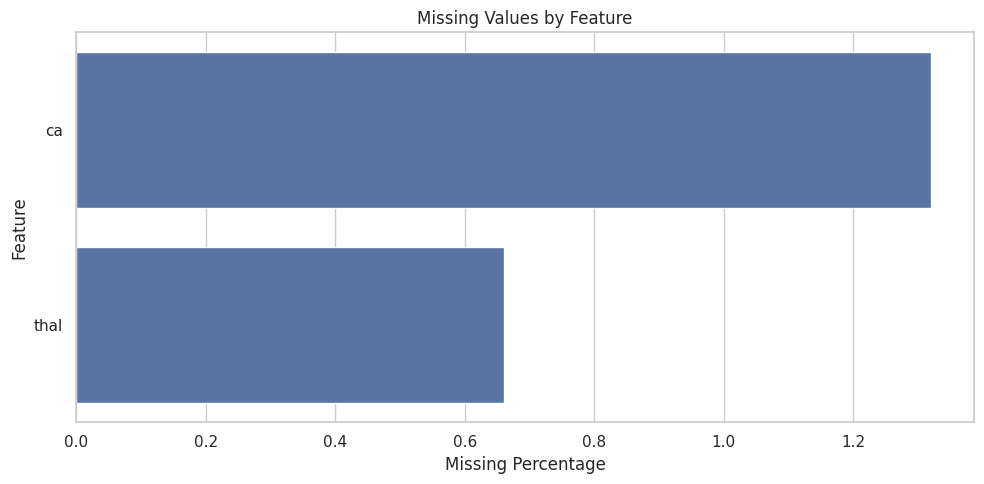

In [ ]:
missing = (
    df.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing = missing[missing > 0]

if len(missing) == 0:

    print("No missing values detected.")

else:

    missing_percent = (
        missing / len(df) * 100
    )

    missing_table = pd.DataFrame({
        "Missing Count": missing,
        "Missing %": missing_percent.round(2)
    })

    display(missing_table)

    plt.figure(figsize=(10, 5))

    sns.barplot(
        x=missing_percent.values,
        y=missing_percent.index
    )

    plt.title("Missing Values by Feature")
    plt.xlabel("Missing Percentage")
    plt.ylabel("Feature")
    plt.tight_layout()
    plt.show()

In [ ]:
numeric_columns = [
    "age",
    "trestbps",
    "chol",
    "thalach",
    "oldpeak"
]

descriptive_stats = df[numeric_columns].describe().T

descriptive_stats["median"] = (
    df[numeric_columns].median()
)

descriptive_stats["variance"] = (
    df[numeric_columns].var()
)

descriptive_stats["skewness"] = (
    df[numeric_columns].skew()
)

descriptive_stats["IQR"] = (
    df[numeric_columns].quantile(0.75)
    -
    df[numeric_columns].quantile(0.25)
)

display(
    descriptive_stats.round(3)
)

descriptive_stats.to_csv(
    "eda_outputs/descriptive_statistics.csv"
)

,count,mean,std,min,25%,50%,75%,max,median,variance,skewness,IQR
age,303.0,54.439,9.039,29.0,48.0,56.0,61.0,77.0,56.0,81.697,-0.209,13.0
trestbps,303.0,131.690,17.600,94.0,120.0,130.0,140.0,200.0,130.0,309.751,0.706,20.0
chol,303.0,246.693,51.777,126.0,211.0,241.0,275.0,564.0,241.0,2680.849,1.136,64.0
thalach,303.0,149.607,22.875,71.0,133.5,153.0,166.0,202.0,153.0,523.266,-0.537,32.5
oldpeak,303.0,1.040,1.161,0.0,0.0,0.8,1.6,6.2,0.8,1.348,1.270,1.6


In [ ]:
skewness_report = []

for col in numeric_columns:

    skew_value = df[col].skew()

    if abs(skew_value) < 0.5:
        interpretation = "Approximately symmetric"

    elif abs(skew_value) < 1:
        interpretation = "Moderately skewed"

    else:
        interpretation = "Highly skewed"

    skewness_report.append({
        "Feature": col,
        "Skewness": round(skew_value, 3),
        "Interpretation": interpretation
    })

skewness_report = pd.DataFrame(skewness_report)

display(skewness_report)

skewness_report.to_csv(
    "eda_outputs/skewness_report.csv",
    index=False
)

,Feature,Skewness,Interpretation
0,age,-0.209,Approximately symmetric
1,trestbps,0.706,Moderately skewed
2,chol,1.136,Highly skewed
3,thalach,-0.537,Moderately skewed
4,oldpeak,1.270,Highly skewed


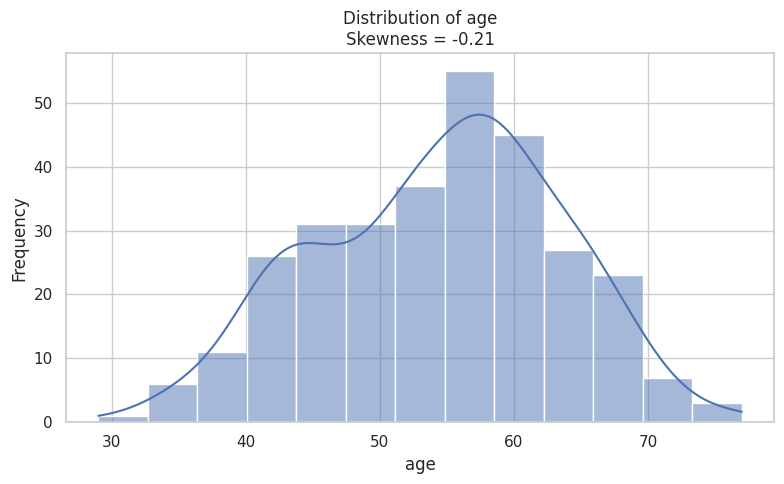

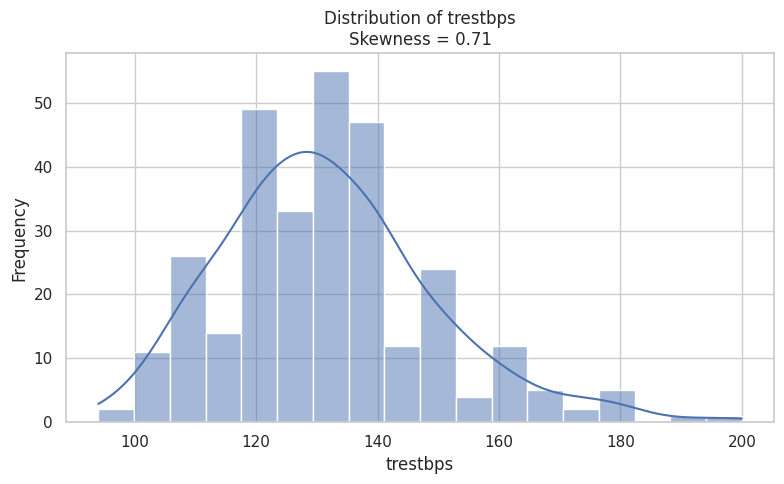

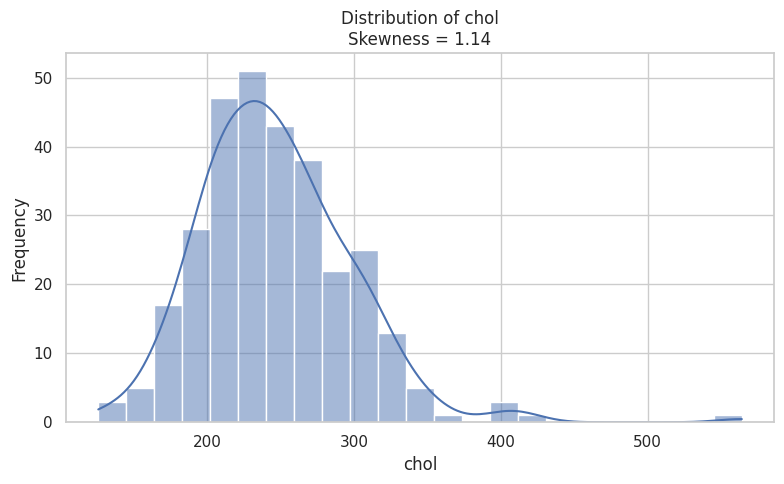

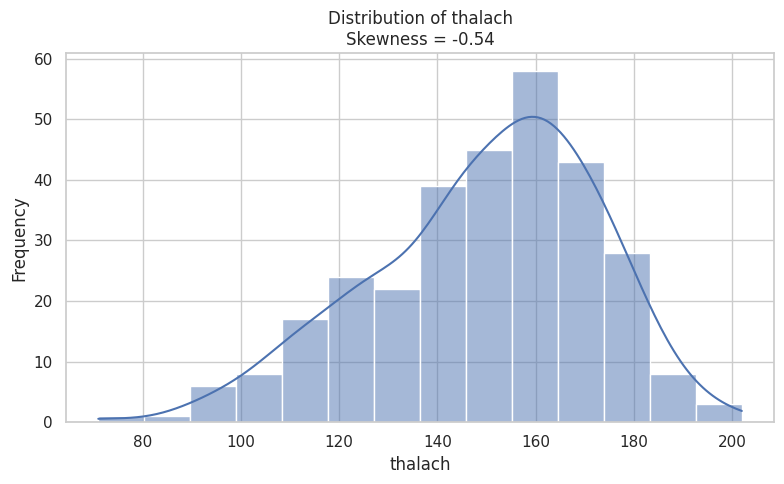

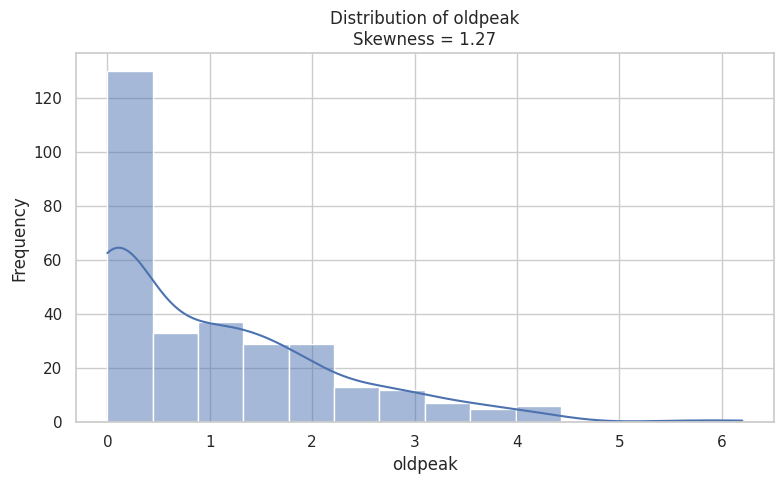

In [ ]:
for col in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=col,
        kde=True
    )

    plt.title(
        f"Distribution of {col}\n"
        f"Skewness = {df[col].skew():.2f}"
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

In [ ]:
outlier_results = []

for col in numeric_columns:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = df[
        (df[col] < lower_bound) |
        (df[col] > upper_bound)
    ]

    outlier_results.append({
        "Feature": col,
        "Q1": round(Q1, 2),
        "Q3": round(Q3, 2),
        "IQR": round(IQR, 2),
        "Lower Bound": round(lower_bound, 2),
        "Upper Bound": round(upper_bound, 2),
        "Outlier Count": len(outliers),
        "Outlier Percentage":
            round(len(outliers) / len(df) * 100, 2)
    })

outlier_report = pd.DataFrame(outlier_results)

display(outlier_report)

outlier_report.to_csv(
    "eda_outputs/outlier_report.csv",
    index=False
)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,age,48.0,61.0,13.0,28.50,80.50,0,0.00
1,trestbps,120.0,140.0,20.0,90.00,170.00,9,2.97
2,chol,211.0,275.0,64.0,115.00,371.00,5,1.65
3,thalach,133.5,166.0,32.5,84.75,214.75,1,0.33
4,oldpeak,0.0,1.6,1.6,-2.40,4.00,5,1.65


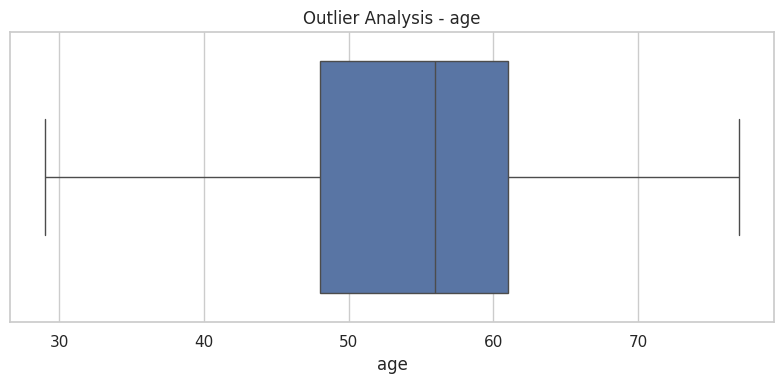

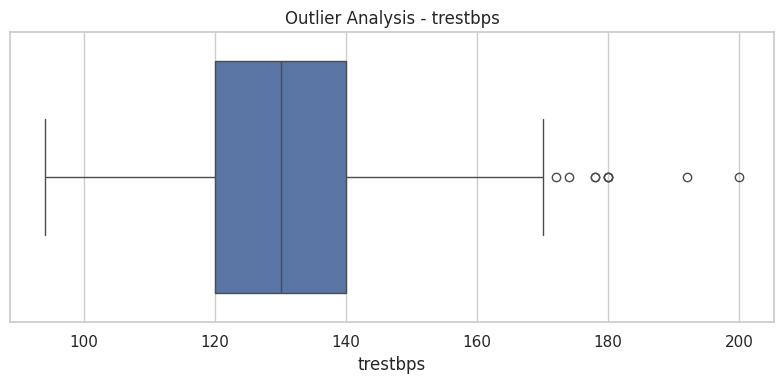

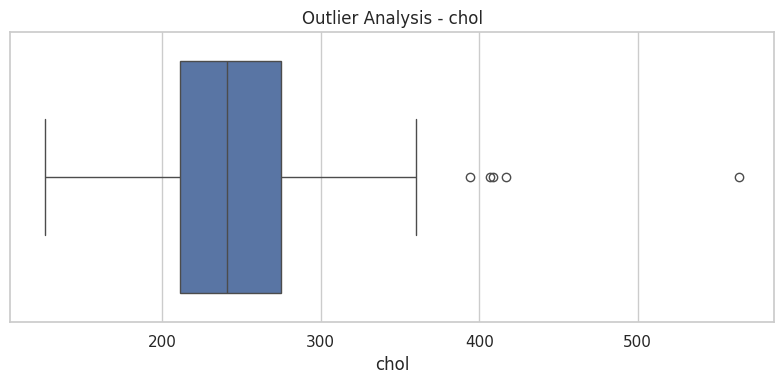

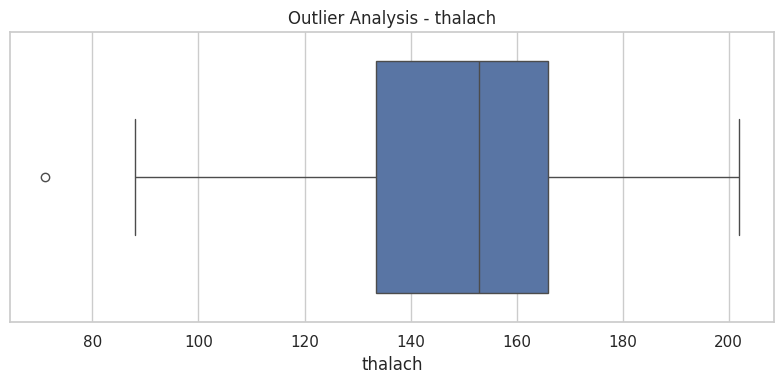

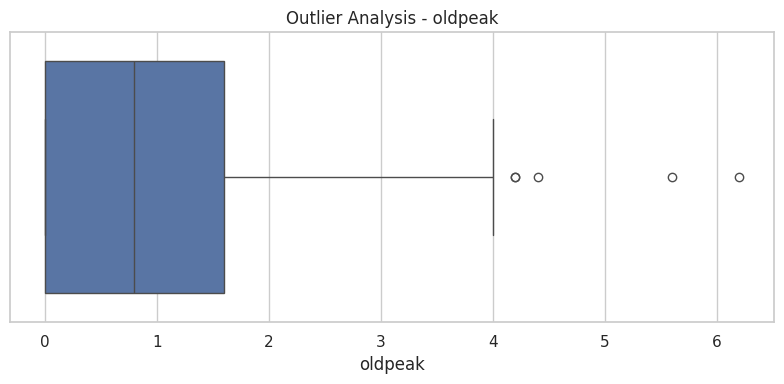

In [ ]:
for col in numeric_columns:

    plt.figure(figsize=(8, 4))

    sns.boxplot(
        x=df[col]
    )

    plt.title(
        f"Outlier Analysis - {col}"
    )

    plt.xlabel(col)

    plt.tight_layout()
    plt.show()


sex


,Count
sex,
0,97
1,206


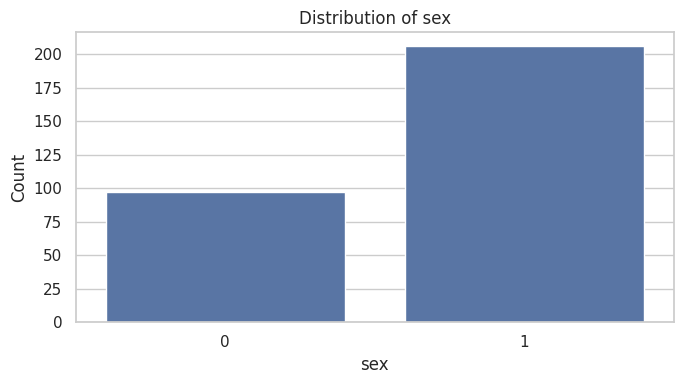


cp


,Count
cp,
1,23
2,50
3,86
4,144


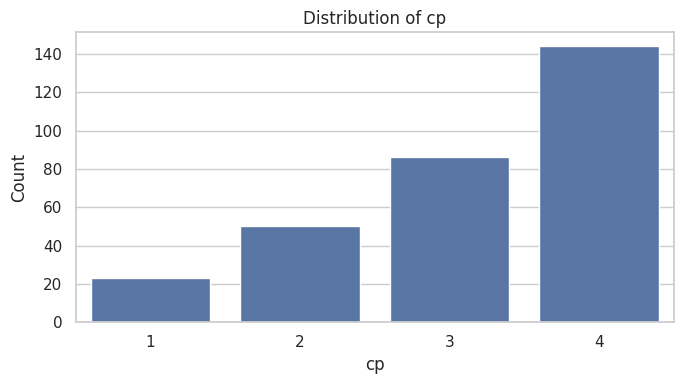


fbs


,Count
fbs,
0,258
1,45


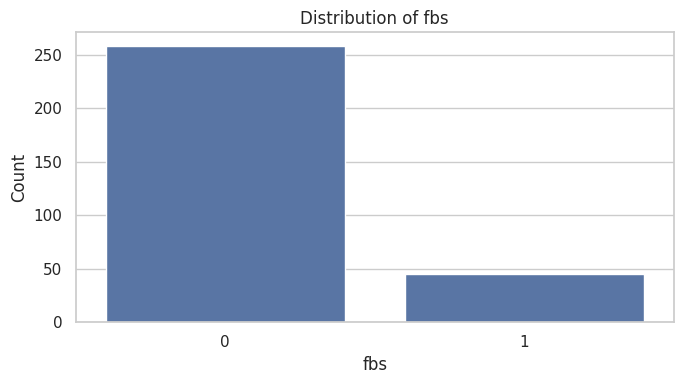


restecg


,Count
restecg,
0,151
1,4
2,148


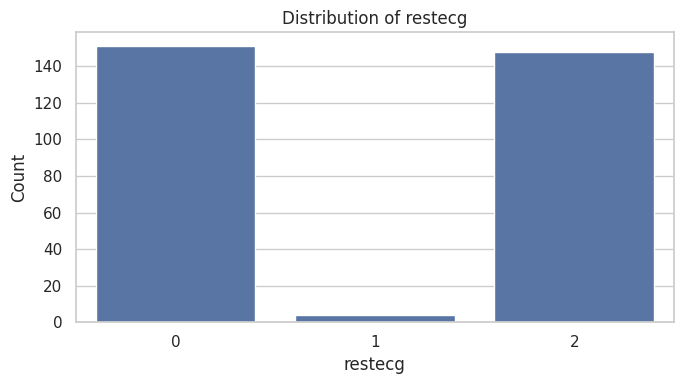


exang


,Count
exang,
0,204
1,99


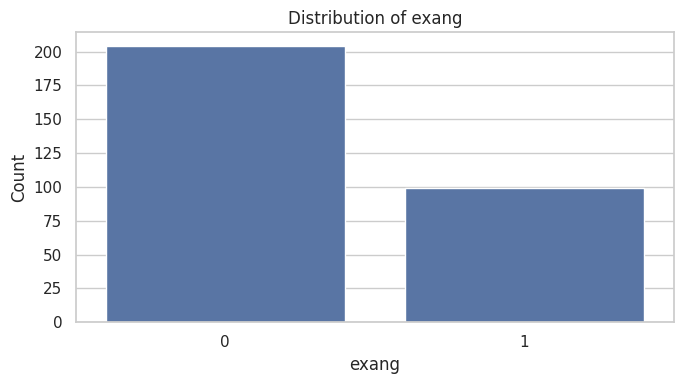


slope


,Count
slope,
1,142
2,140
3,21


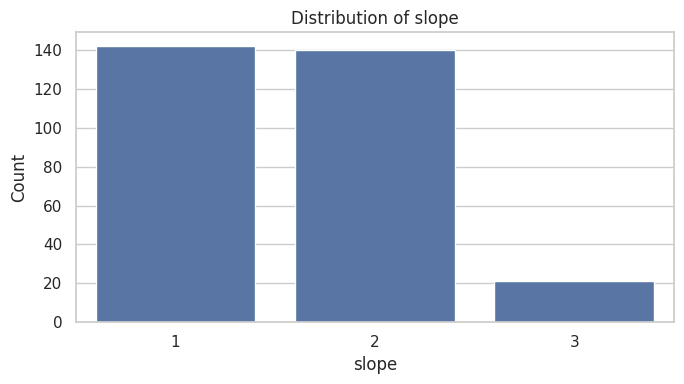


ca


,Count
ca,
0.0,176
1.0,65
2.0,38
3.0,20
NaN,4


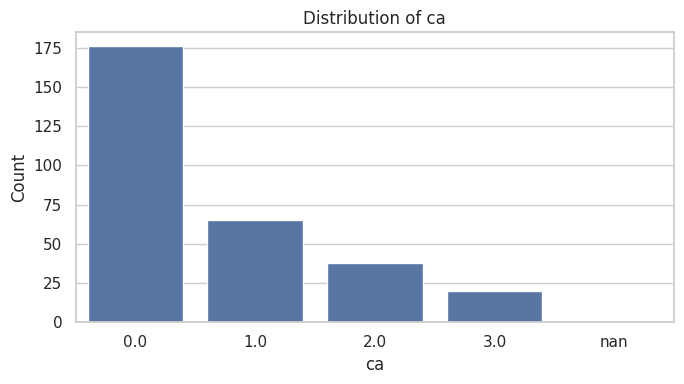


thal


,Count
thal,
3.0,166
6.0,18
7.0,117
NaN,2


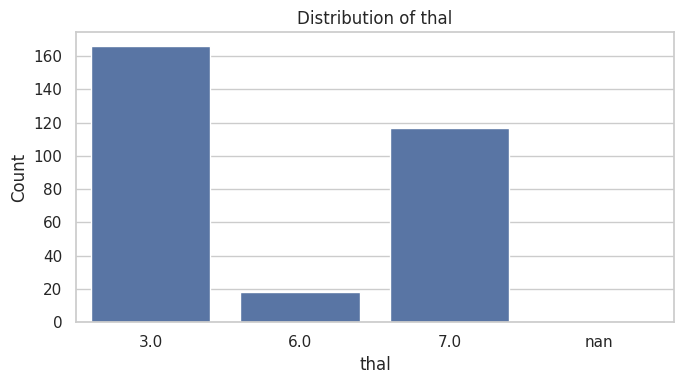

In [ ]:
categorical_columns = [
    "sex",
    "cp",
    "fbs",
    "restecg",
    "exang",
    "slope",
    "ca",
    "thal"
]

for col in categorical_columns:

    counts = (
        df[col]
        .value_counts(dropna=False)
        .sort_index()
    )

    print(f"\n{col}")
    display(counts.to_frame("Count"))

    plt.figure(figsize=(7, 4))

    sns.countplot(
        data=df,
        x=col,
        order=counts.index
    )

    plt.title(
        f"Distribution of {col}"
    )

    plt.xlabel(col)
    plt.ylabel("Count")

    plt.tight_layout()
    plt.show()

Binary target distribution:


,Count
target_label,
No Disease,164
Disease,139



Target percentage:


,Percentage
target_label,
No Disease,54.13
Disease,45.87


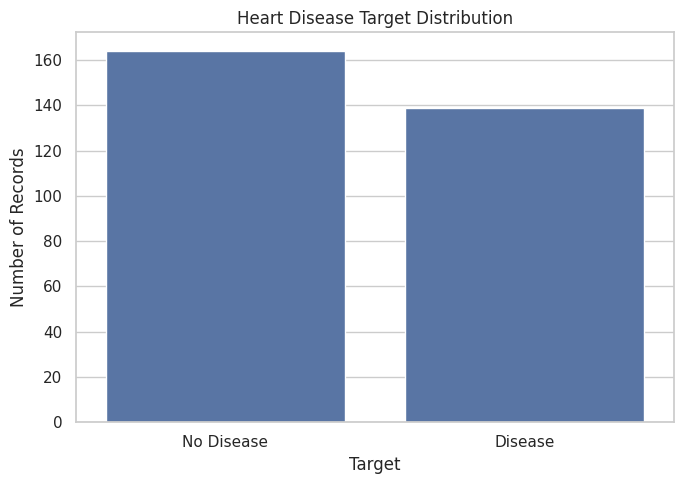

In [ ]:
target_counts = df["target_label"].value_counts()

print("Binary target distribution:")
display(target_counts.to_frame("Count"))

print("\nTarget percentage:")
display(
    (
        target_counts /
        len(df) *
        100
    ).round(2).to_frame("Percentage")
)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="target_label"
)

plt.title(
    "Heart Disease Target Distribution"
)

plt.xlabel("Target")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

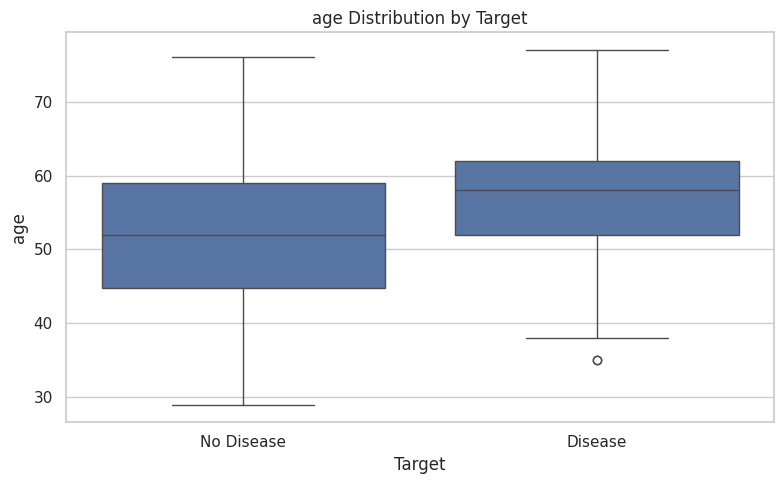

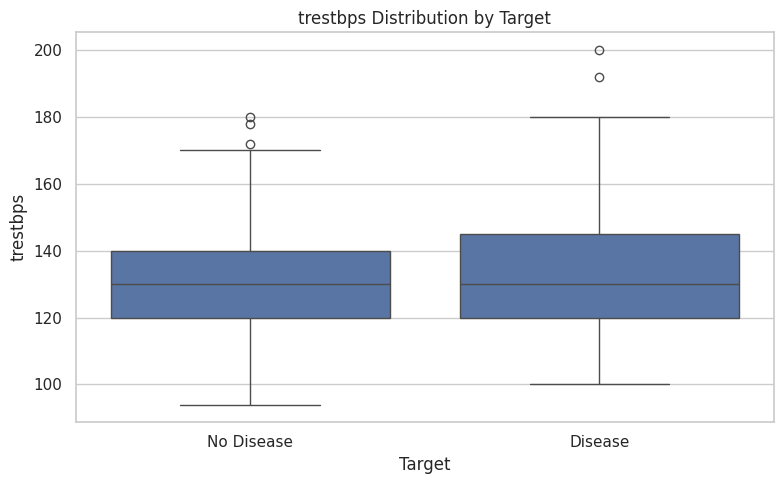

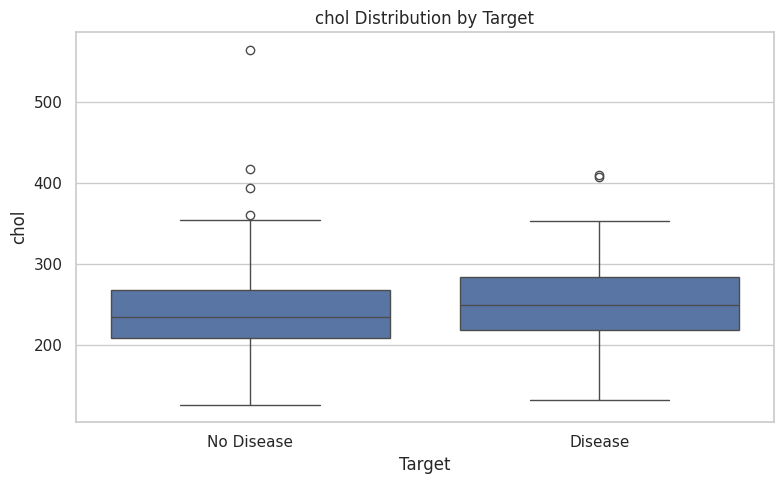

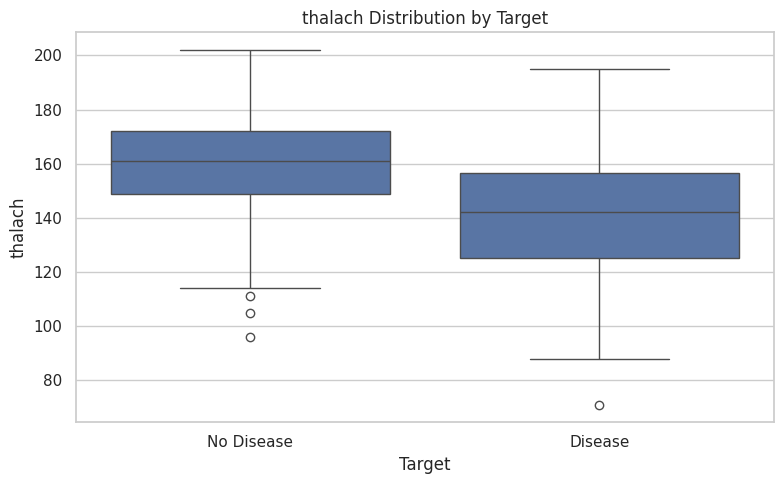

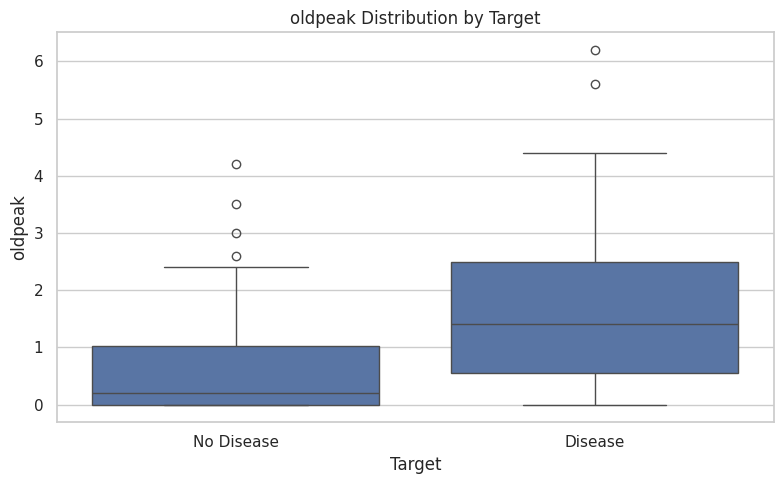

In [ ]:
for col in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="target_label",
        y=col
    )

    plt.title(
        f"{col} Distribution by Target"
    )

    plt.xlabel("Target")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

Binary target distribution:


,Count
target_label,
No Disease,164
Disease,139



Target percentage:


,Percentage
target_label,
No Disease,54.13
Disease,45.87


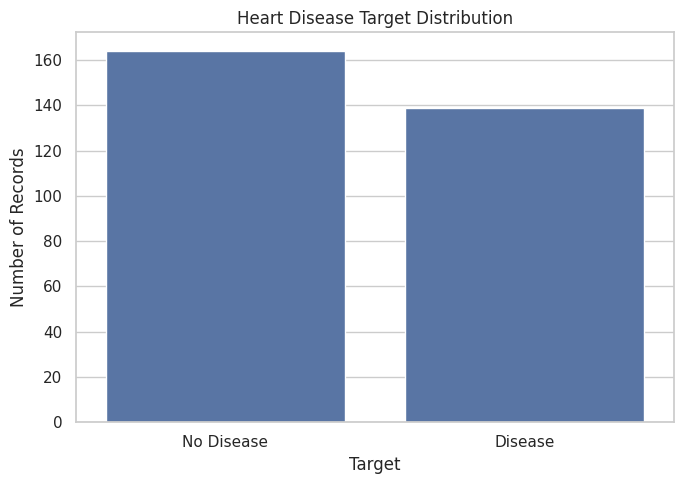

In [ ]:
target_counts = df["target_label"].value_counts()

print("Binary target distribution:")
display(target_counts.to_frame("Count"))

print("\nTarget percentage:")
display(
    (
        target_counts /
        len(df) *
        100
    ).round(2).to_frame("Percentage")
)

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df,
    x="target_label"
)

plt.title(
    "Heart Disease Target Distribution"
)

plt.xlabel("Target")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

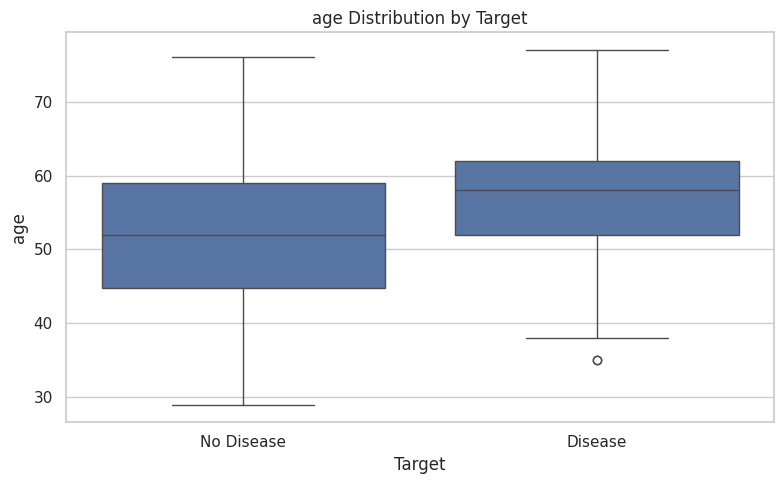

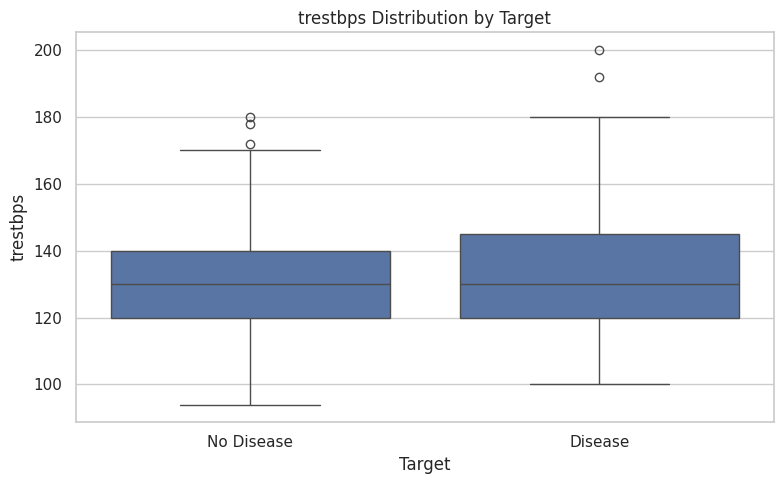

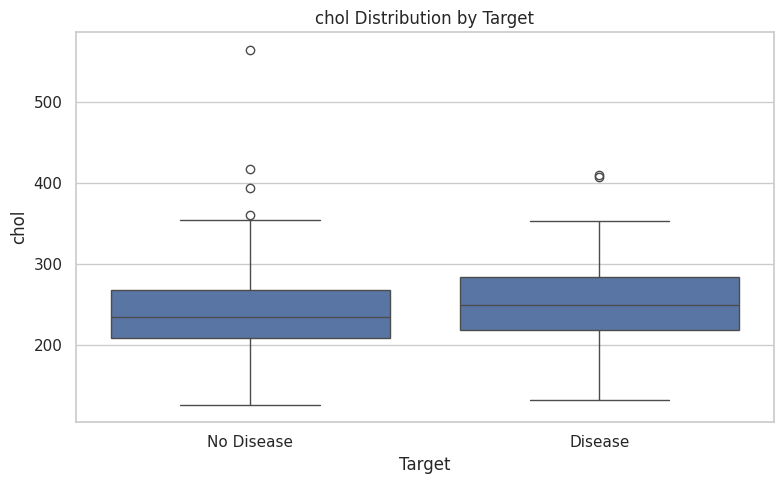

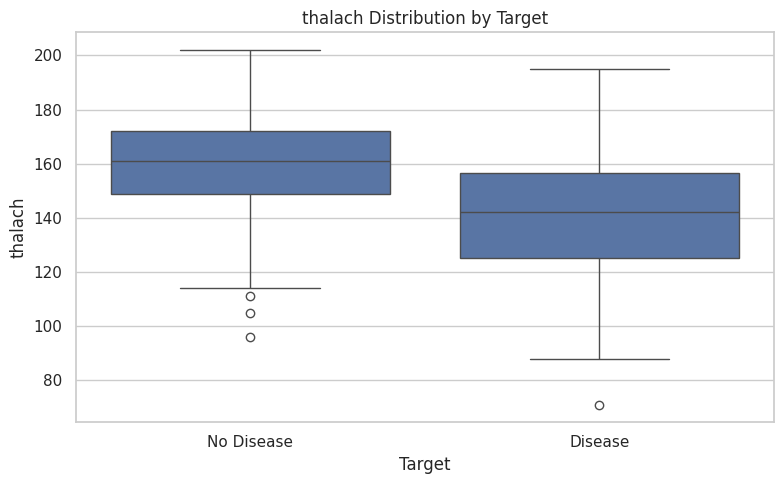

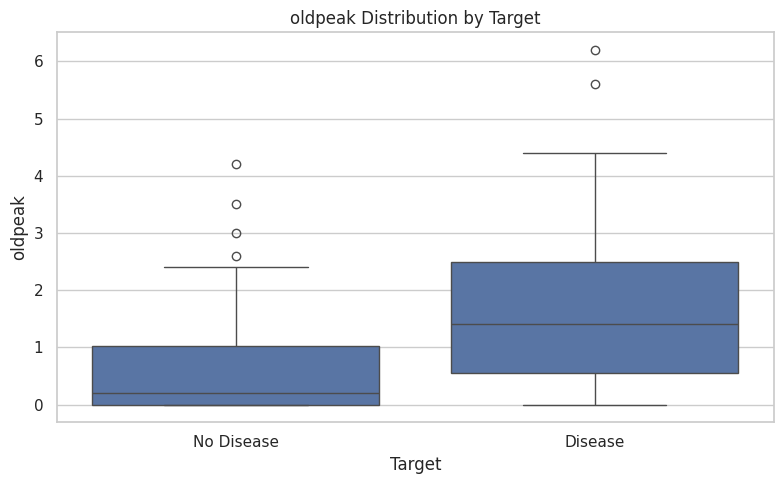

In [ ]:

for col in numeric_columns:

    plt.figure(figsize=(8, 5))

    sns.boxplot(
        data=df,
        x="target_label",
        y=col
    )

    plt.title(
        f"{col} Distribution by Target"
    )

    plt.xlabel("Target")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [ ]:
target_summary = (
    df.groupby("target_label")[numeric_columns]
    .agg(["mean", "median", "std"])
)

display(target_summary.round(2))

target_summary.to_csv(
    "eda_outputs/target_wise_numeric_summary.csv"
)

age              trestbps                  chol                \
               mean median   std     mean median    std    mean median    std   
target_label                                                                    
Disease       56.63   58.0  7.94   134.57  130.0  18.77  251.47  249.0  49.49   
No Disease    52.59   52.0  9.51   129.25  130.0  16.20  242.64  234.5  53.46   

             thalach               oldpeak               
                mean median    std    mean median   std  
target_label                                             
Disease       139.26  142.0  22.59    1.57    1.4  1.30  
No Disease    158.38  161.0  19.20    0.59    0.2  0.78

In [ ]:
association_results = []

for col in numeric_columns:

    temp = df[[col, "target"]].dropna()

    correlation, p_value = pointbiserialr(
        temp["target"],
        temp[col]
    )

    association_results.append({
        "Feature": col,
        "Correlation": round(correlation, 4),
        "P_Value": round(p_value, 6),
        "Absolute_Correlation":
            round(abs(correlation), 4)
    })

numeric_association = (
    pd.DataFrame(association_results)
    .sort_values(
        "Absolute_Correlation",
        ascending=False
    )
)

display(numeric_association)

numeric_association.to_csv(
    "eda_outputs/numeric_target_association.csv",
    index=False
)

,Feature,Correlation,P_Value,Absolute_Correlation
4,oldpeak,0.4245,0.000000,0.4245
3,thalach,-0.4172,0.000000,0.4172
0,age,0.2231,0.000090,0.2231
1,trestbps,0.1508,0.008548,0.1508
2,chol,0.0852,0.139142,0.0852


In [ ]:
correlation_data = df[
    numeric_columns + ["target"]
]

spearman_corr = correlation_data.corr(
    method="spearman"
)

display(
    spearman_corr.round(3)
)

,age,trestbps,chol,thalach,oldpeak,target
age,1.000,0.292,0.191,-0.392,0.260,0.237
trestbps,0.292,1.000,0.136,-0.040,0.150,0.128
chol,0.191,0.136,1.000,-0.038,0.034,0.121
thalach,-0.392,-0.040,-0.038,1.000,-0.432,-0.423
oldpeak,0.260,0.150,0.034,-0.432,1.000,0.413
target,0.237,0.128,0.121,-0.423,0.413,1.000


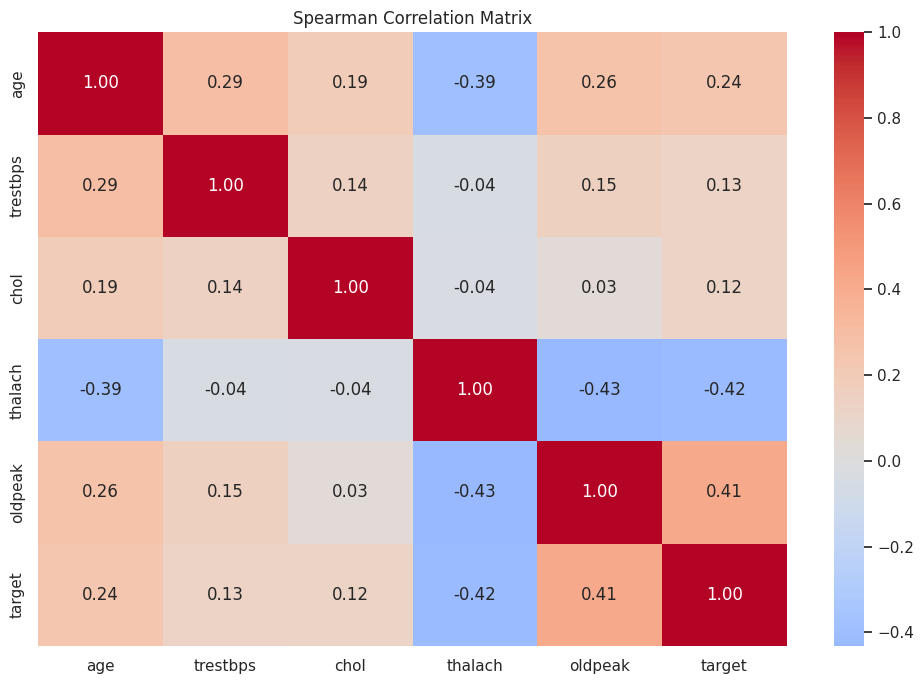

In [ ]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    spearman_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Spearman Correlation Matrix"
)

plt.tight_layout()
plt.show()

In [ ]:
spearman_corr.to_csv(
    "eda_outputs/spearman_correlation_matrix.csv"
)

In [ ]:
corr_pairs = []

for i in range(len(numeric_columns)):

    for j in range(i + 1, len(numeric_columns)):

        feature_1 = numeric_columns[i]
        feature_2 = numeric_columns[j]

        corr_value = spearman_corr.loc[
            feature_1,
            feature_2
        ]

        corr_pairs.append({
            "Feature 1": feature_1,
            "Feature 2": feature_2,
            "Spearman Correlation":
                round(corr_value, 4),
            "Absolute Correlation":
                round(abs(corr_value), 4)
        })

corr_pairs = (
    pd.DataFrame(corr_pairs)
    .sort_values(
        "Absolute Correlation",
        ascending=False
    )
)

print("Strongest numerical feature relationships:")

display(
    corr_pairs.head(10)
)

corr_pairs.to_csv(
    "eda_outputs/strongest_feature_correlations.csv",
    index=False
)

Strongest numerical feature relationships:


,Feature 1,Feature 2,Spearman Correlation,Absolute Correlation
9,thalach,oldpeak,-0.4315,0.4315
2,age,thalach,-0.3916,0.3916
0,age,trestbps,0.2922,0.2922
3,age,oldpeak,0.2599,0.2599
1,age,chol,0.1913,0.1913
6,trestbps,oldpeak,0.1502,0.1502
4,trestbps,chol,0.1358,0.1358
5,trestbps,thalach,-0.0404,0.0404
7,chol,thalach,-0.0383,0.0383
8,chol,oldpeak,0.0344,0.0344


In [ ]:
def cramers_v(x, y):

    table = pd.crosstab(x, y)

    chi2 = chi2_contingency(table)[0]

    n = table.sum().sum()

    phi2 = chi2 / n

    rows, cols = table.shape

    phi2_corrected = max(
        0,
        phi2 -
        ((cols - 1) * (rows - 1)) /
        (n - 1)
    )

    rows_corrected = (
        rows -
        ((rows - 1) ** 2) /
        (n - 1)
    )

    cols_corrected = (
        cols -
        ((cols - 1) ** 2) /
        (n - 1)
    )

    denominator = min(
        cols_corrected - 1,
        rows_corrected - 1
    )

    if denominator <= 0:
        return 0

    return np.sqrt(
        phi2_corrected / denominator
    )

In [ ]:
categorical_association = []

for col in categorical_columns:

    temp = df[[col, "target"]].dropna()

    value = cramers_v(
        temp[col],
        temp["target"]
    )

    categorical_association.append({
        "Feature": col,
        "Cramers_V": round(value, 4)
    })

categorical_association = (
    pd.DataFrame(categorical_association)
    .sort_values(
        "Cramers_V",
        ascending=False
    )
)

display(categorical_association)

categorical_association.to_csv(
    "eda_outputs/categorical_target_association.csv",
    index=False
)


,Feature,Cramers_V
7,thal,0.5205
1,cp,0.5108
6,ca,0.4806
4,exang,0.4216
5,slope,0.3807
0,sex,0.2639
3,restecg,0.1632
2,fbs,0.0000


In [ ]:
chi_square_results = []

for col in categorical_columns:

    temp = df[[col, "target"]].dropna()

    contingency_table = pd.crosstab(
        temp[col],
        temp["target"]
    )

    chi2, p_value, dof, expected = (
        chi2_contingency(contingency_table)
    )

    chi_square_results.append({
        "Feature": col,
        "Chi2": round(chi2, 4),
        "P_Value": round(p_value, 6),
        "Degrees_of_Freedom": dof,
        "Significant_at_0.05":
            p_value < 0.05
    })

chi_square_results = pd.DataFrame(
    chi_square_results
).sort_values(
    "P_Value"
)

display(chi_square_results)

chi_square_results.to_csv(
    "eda_outputs/chi_square_tests.csv",
    index=False
)

,Feature,Chi2,P_Value,Degrees_of_Freedom,Significant_at_0.05
1,cp,81.8158,0.000000,3,True
6,ca,71.8431,0.000000,3,True
5,slope,45.7846,0.000000,2,True
4,exang,54.6864,0.000000,1,True
7,thal,83.2895,0.000000,2,True
0,sex,22.0426,0.000003,1,True
3,restecg,10.0515,0.006567,2,True
2,fbs,0.0771,0.781273,1,False


In [ ]:
mann_whitney_results = []

for col in numeric_columns:

    group_0 = df.loc[
        df["target"] == 0,
        col
    ].dropna()

    group_1 = df.loc[
        df["target"] == 1,
        col
    ].dropna()

    statistic, p_value = mannwhitneyu(
        group_0,
        group_1,
        alternative="two-sided"
    )

    mann_whitney_results.append({
        "Feature": col,
        "U_Statistic": round(statistic, 3),
        "P_Value": round(p_value, 6),
        "Significant_at_0.05":
            p_value < 0.05
    })

mann_whitney_results = pd.DataFrame(
    mann_whitney_results
).sort_values(
    "P_Value"
)

display(mann_whitney_results)

mann_whitney_results.to_csv(
    "eda_outputs/mann_whitney_tests.csv",
    index=False
)

,Feature,U_Statistic,P_Value,Significant_at_0.05
3,thalach,16989.5,0.000000,True
4,oldpeak,6037.0,0.000000,True
0,age,8274.5,0.000039,True
1,trestbps,9710.0,0.025972,True
2,chol,9798.5,0.035359,True


In [ ]:
df["age_group"] = pd.cut(
    df["age"],
    bins=[0, 40, 50, 60, 70, 100],
    labels=[
        "<40",
        "40-49",
        "50-59",
        "60-69",
        "70+"
    ]
)

age_target = pd.crosstab(
    df["age_group"],
    df["target"],
    normalize="index"
) * 100

age_target.columns = [
    "No Disease %",
    "Disease %"
]

print("Age group × target:")
display(age_target.round(2))

Age group × target:


,No Disease %,Disease %
age_group,,
<40,66.67,33.33
40-49,69.74,30.26
50-59,49.23,50.77
60-69,41.10,58.90
70+,83.33,16.67


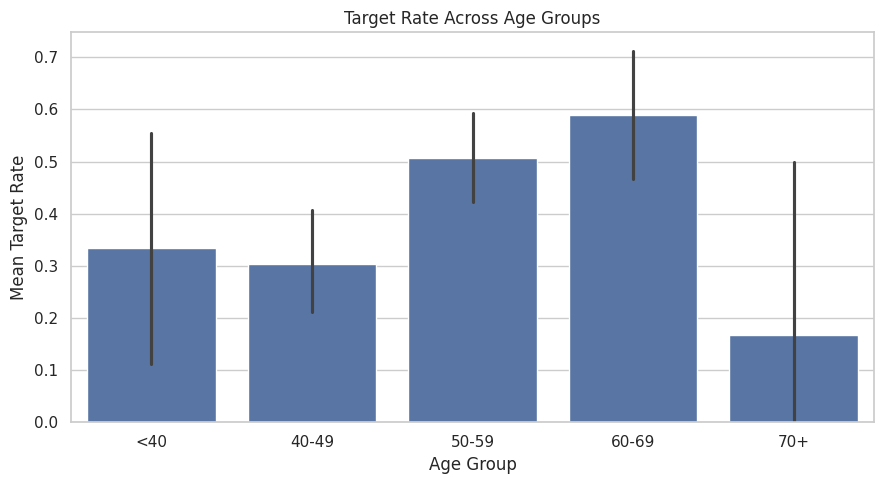

In [ ]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="age_group",
    y="target"
)

plt.title(
    "Target Rate Across Age Groups"
)

plt.xlabel("Age Group")
plt.ylabel("Mean Target Rate")

plt.tight_layout()
plt.show()

Chest pain type × target:


,No Disease %,Disease %
cp,,
1,69.57,30.43
2,82.00,18.00
3,79.07,20.93
4,27.08,72.92


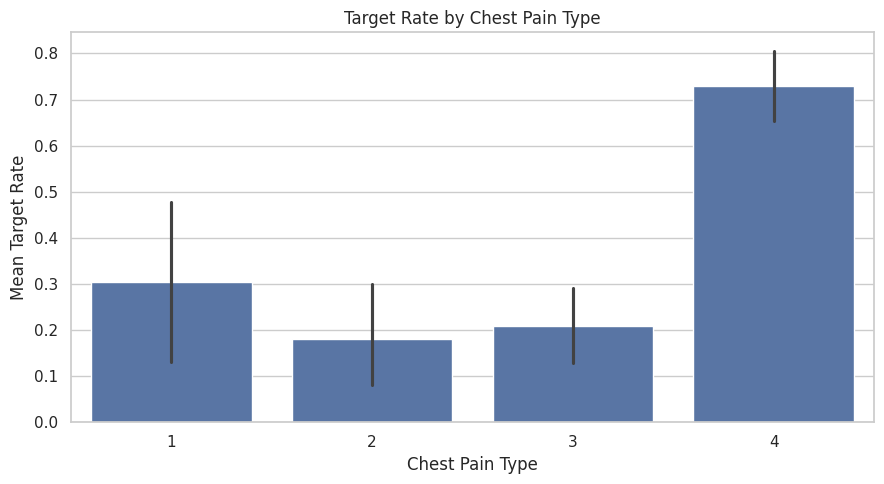

In [ ]:
cp_target = pd.crosstab(
    df["cp"],
    df["target"],
    normalize="index"
) * 100

cp_target.columns = [
    "No Disease %",
    "Disease %"
]

print("Chest pain type × target:")
display(cp_target.round(2))

plt.figure(figsize=(9, 5))

sns.barplot(
    data=df,
    x="cp",
    y="target"
)

plt.title(
    "Target Rate by Chest Pain Type"
)

plt.xlabel("Chest Pain Type")
plt.ylabel("Mean Target Rate")

plt.tight_layout()
plt.show()

In [ ]:
exang_target = pd.crosstab(
    df["exang"],
    df["target"],
    normalize="index"
) * 100

exang_target.columns = [
    "No Disease %",
    "Disease %"
]

print("Exercise-induced angina × target:")
display(exang_target.round(2))

Exercise-induced angina × target:


,No Disease %,Disease %
exang,,
0,69.12,30.88
1,23.23,76.77


In [ ]:
print("=" * 70)
print("TOP 3 ACTIONABLE DATA INSIGHTS")
print("=" * 70)

# INSIGHT 1: Strongest numerical target association

strongest_numeric = (
    numeric_association.iloc[0]
)

feature_1 = strongest_numeric["Feature"]
corr_1 = strongest_numeric["Correlation"]

insight_1 = (
    f"1. {feature_1} shows the strongest numerical "
    f"association with the project target among the "
    f"analyzed numerical features "
    f"(point-biserial correlation = {corr_1:.3f}). "
    f"Action: prioritize this feature for deeper "
    f"feature-analysis and model interpretation, "
    f"while avoiding causal interpretation."
)



# INSIGHT 2: Strongest categorical target association

strongest_categorical = (
    categorical_association.iloc[0]
)

feature_2 = strongest_categorical["Feature"]
cramer_2 = strongest_categorical["Cramers_V"]

insight_2 = (
    f"2. {feature_2} has the strongest categorical "
    f"association with the project target based on "
    f"Cramér's V = {cramer_2:.3f}. "
    f"Action: retain this feature for further modeling "
    f"analysis and investigate its category-level "
    f"target distribution."
)



# INSIGHT 3: Most skewed feature

most_skewed = (
    skewness_report
    .assign(
        Abs_Skew=lambda x:
        x["Skewness"].abs()
    )
    .sort_values(
        "Abs_Skew",
        ascending=False
    )
    .iloc[0]
)

feature_3 = most_skewed["Feature"]
skew_3 = most_skewed["Skewness"]

insight_3 = (
    f"3. {feature_3} has the largest absolute "
    f"skewness ({skew_3:.3f}) among the numerical "
    f"features. "
    f"Action: flag this distribution for the modeling "
    f"team to consider when selecting transformations "
    f"or algorithms."
)


print(insight_1)
print()
print(insight_2)
print()
print(insight_3)

TOP 3 ACTIONABLE DATA INSIGHTS
1. oldpeak shows the strongest numerical association with the project target among the analyzed numerical features (point-biserial correlation = 0.424). Action: prioritize this feature for deeper feature-analysis and model interpretation, while avoiding causal interpretation.

2. thal has the strongest categorical association with the project target based on Cramér's V = 0.520. Action: retain this feature for further modeling analysis and investigate its category-level target distribution.

3. oldpeak has the largest absolute skewness (1.270) among the numerical features. Action: flag this distribution for the modeling team to consider when selecting transformations or algorithms.


In [ ]:
insights_df = pd.DataFrame({
    "Insight_Number": [1, 2, 3],
    "Insight": [
        insight_1,
        insight_2,
        insight_3
    ]
})

display(insights_df)

insights_df.to_csv(
    "eda_outputs/top_3_actionable_insights.csv",
    index=False
)

,Insight_Number,Insight
0,1,1. oldpeak shows the strongest numerical assoc...
1,2,2. thal has the strongest categorical associat...
2,3,3. oldpeak has the largest absolute skewness (...


In [ ]:
print("=" * 70)
print("DATA ANALYST DELIVERABLES")
print("=" * 70)

deliverables = {
    "Visual EDA section": "COMPLETED",
    "Descriptive statistical analysis": "COMPLETED",
    "Distribution analysis": "COMPLETED",
    "Skewness analysis": "COMPLETED",
    "Categorical distribution analysis": "COMPLETED",
    "Target distribution analysis": "COMPLETED",
    "Anomaly / outlier detection": "COMPLETED",
    "Numerical correlation analysis": "COMPLETED",
    "Numerical feature-target association": "COMPLETED",
    "Categorical feature-target association": "COMPLETED",
    "Chi-square statistical testing": "COMPLETED",
    "Mann-Whitney statistical testing": "COMPLETED",
    "Feature interaction analysis": "COMPLETED",
    "Top 3 actionable insights": "COMPLETED"
}

for item, status in deliverables.items():
    print(f"{item:<50} {status}")


print("\nGenerated EDA files:")

for file in sorted(os.listdir("eda_outputs")):
    print(" -", file)

DATA ANALYST DELIVERABLES
Visual EDA section                                 COMPLETED
Descriptive statistical analysis                   COMPLETED
Distribution analysis                              COMPLETED
Skewness analysis                                  COMPLETED
Categorical distribution analysis                  COMPLETED
Target distribution analysis                       COMPLETED
Anomaly / outlier detection                        COMPLETED
Numerical correlation analysis                     COMPLETED
Numerical feature-target association               COMPLETED
Categorical feature-target association             COMPLETED
Chi-square statistical testing                     COMPLETED
Mann-Whitney statistical testing                   COMPLETED
Feature interaction analysis                       COMPLETED
Top 3 actionable insights                          COMPLETED

Generated EDA files:
 - categorical_target_association.csv
 - chi_square_tests.csv
 - data_quality_report.csv
 - descri